## How to write and read BIDS data

In the BIDS format, there is a bit of information that is not currently in the data formats.  Specifically, there is a ReadMe and dataset description JSON file, along with metadata like units and variable descritions on demographics variables.  The official NIRS-BIDS format has many additional (and in my opinion unnessacary) fields in the demographics which if not present in the SNIRS files, will cause BIDS-validation warnings.   

In [1]:
import pyBrainAnalyzIR.io.bids as bids
from pathlib import Path

import pandas as pd
import pyBrainAnalyzIR.testing
import pyBrainAnalyzIR.dataclasses.dataset as dataset

from pyBrainAnalyzIR.vis import demographics_manager


from cedalion.io.snirf import read_snirf
from cedalion.io.snirf import write_snirf


from pyBrainAnalyzIR.vis.plot_nirs_inline import plot as nirs_show

import pprint
import cedalion
import pint
units = cedalion.units

In [2]:
dset=dataset.DataSet()
data1,_=pyBrainAnalyzIR.testing.simData.Data(snr=5)
data2,_=pyBrainAnalyzIR.testing.simData.Data(snr=5)
data3,_=pyBrainAnalyzIR.testing.simData.Data(snr=5)
data4,_=pyBrainAnalyzIR.testing.simData.Data(snr=5)
data5,_=pyBrainAnalyzIR.testing.simData.Data(snr=5)
data6,_=pyBrainAnalyzIR.testing.simData.Data(snr=5)

dset.import_data(data1)
dset.import_data(data2)
dset.import_data(data3)
dset.import_data(data4)
dset.import_data(data5)
dset.import_data(data6)

demo=pd.DataFrame({'subject':['A','B','C','D','E','F'],'gender':['M','M','F','F','M','F'],'age':[1.,3.,5.,6.,1.,3.]})
dset.add_demographics_by_index(demo)

 94%|█████████▍| 15/16 [00:00<00:00, 890.95it/s]


The dataset allows you to add additional information for the units and descriptions attached to metadata.  This can be done via command line (shown here) or using the demographics_manager GUI

In [3]:
dset.add_meta_data_description('subject', 'The subject ID.')
dset.add_meta_data_description('age', 'The age of the subject.')
dset.add_meta_data_description('gender', 'The gender of the subject.')

dset.add_demographics_units('age', units.years)

In [4]:
demo=dset.get_demographics()
print(demo)

  subject gender       age
0       A      M  1.0 year
1       B      M  3.0 year
2       C      F  5.0 year
3       D      F  6.0 year
4       E      M  1.0 year
5       F      F  3.0 year


In [5]:
# This is a template from the BIDS site.  You can modify, remove, or add sections as needed for your dataset.
ReadMe = bids.bids_README_template()

ReadMe['Overview'] = "Sample data in BIDS format."
ReadMe['Contact'] = " Theodore Huppert <theodore.huppert@stonybrookmedicine.edu>"
ReadMe['How to use these data'] = "Raw data to read into pyNIRStoolbox."

ReadMe['Dataset contents and structure'] = "Simulated data for testing BIDS."
ReadMe['Participants and recruitment'] = "Describe the participants and recruitment process here."

ReadMe['Methods'] = "Describe the methods used in the study here."
ReadMe['Acquisition'] = "SImulated data from pyNIRStoolbox."
ReadMe['Additional data acquired'] = "Non-imaging data collected as part of the study: None"

ReadMe['Experimental design'] = "Describe the experimental design here."
ReadMe['Task and paradigm'] = 'Simulated task for testing BIDS.'
ReadMe['Stimuli'] = "Describe the stimuli used in the study here."

ReadMe['Known issues, quality, and missing data'] = "None known."
ReadMe['References and citation'] = "Provide references and citation information for the dataset here."

pprint.pprint(ReadMe)

{'Acquisition': 'SImulated data from pyNIRStoolbox.',
 'Additional data acquired': 'Non-imaging data collected as part of the study: '
                             'None',
 'Contact': ' Theodore Huppert <theodore.huppert@stonybrookmedicine.edu>',
 'Dataset contents and structure': 'Simulated data for testing BIDS.',
 'Experimental design': 'Describe the experimental design here.',
 'How to use these data': 'Raw data to read into pyNIRStoolbox.',
 'How to use these data ': 'Preprocessing already applied (and where it '
                           'lives), recommended reference/montage, software + '
                           'version, or analysis tips.',
 'Known issues, quality, and missing data': 'None known.',
 'Methods': 'Describe the methods used in the study here.',
 'Overview': 'Sample data in BIDS format.',
 'Participants and recruitment': 'Describe the participants and recruitment '
                                 'process here.',
 'References and citation': 'Provide references 

In [6]:
dataset_description = bids.bids_dataset_description_template()

dataset_description['Authors']=['T. Huppert','H. Santosa']
dataset_description['Funding']=['NIH R01EB025209']
dataset_description['ReferencesAndLinks']=['https://github.com/huppertt/pyNIRS_toolbox','https://huppertlab.net/']
dataset_description['Acknowledgements']=['This code was developed by the Huppert Lab.']
dataset_description['How To Acknowledge']=['Please cite the associated publications when using this dataset.']

pprint.pprint(dataset_description)

{'Acknowledgements': ['This code was developed by the Huppert Lab.'],
 'Authors': ['T. Huppert', 'H. Santosa'],
 'BIDSVersion': '1.10.0',
 'DatasetDOI': 'doi',
 'Funding': ['NIH R01EB025209'],
 'How To Acknowledge': ['Please cite the associated publications when using '
                        'this dataset.'],
 'License': 'CC0',
 'Name': 'Dataset Name',
 'ReferencesAndLinks': ['https://github.com/huppertt/pyNIRS_toolbox',
                        'https://huppertlab.net/']}


Write the data to BIDS. 

In [7]:
datapath = Path('/Users/theodorehuppert/Desktop/Bids_Test')
bids.write_bids_dataset(dset,path=datapath,dataset_description=dataset_description,readme=ReadMe)

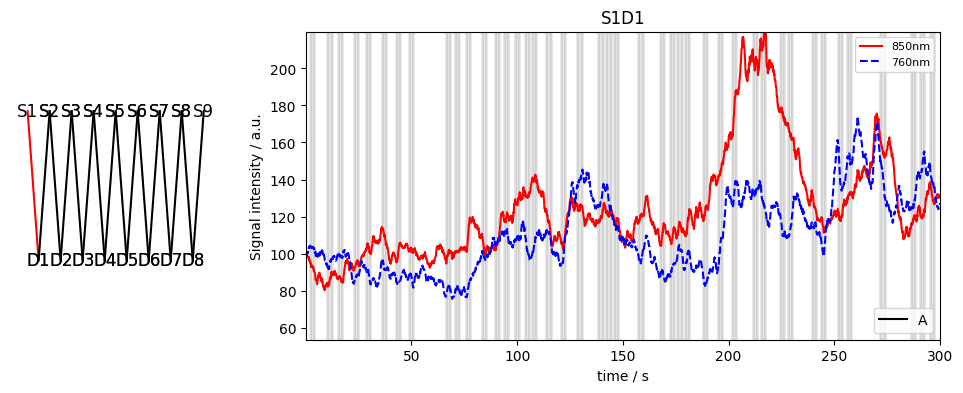

In [8]:
nirs_show(dset.dataset[0],'amp')

Now, let's read the data back and plot the same file.

In [10]:
dset2 = bids.read_bids_dataset(datapath)

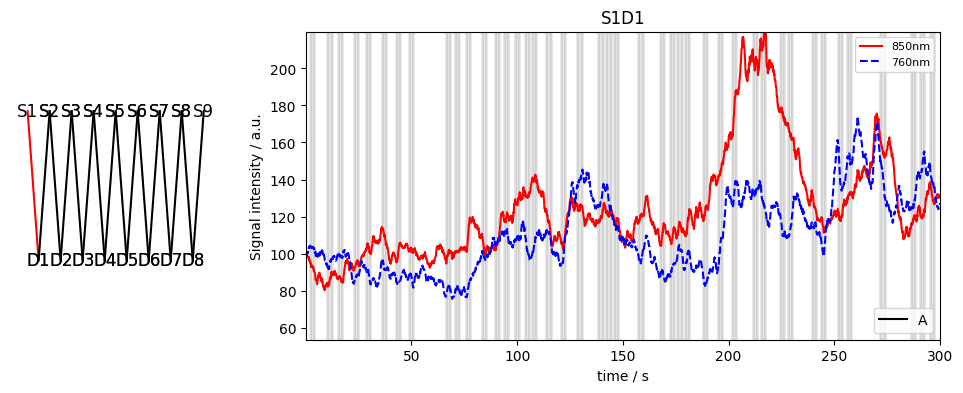

In [11]:
nirs_show(dset2.dataset[0],'amp')